# Analyse exploratoire des données Polypbase

Ce notebook est une **première analyse exploratoire** des anciens fichiers Excel de suivi des polypes.

L’objectif est simple : comprendre la structure des fichiers, transformer les tableaux Excel en données exploitables, puis produire des premiers résultats lisibles.

Les résultats doivent rester prudents : ils montrent des tendances ou des points à vérifier, mais ils ne prouvent pas encore une relation biologique certaine. Par exemple, une cellule vide n’est pas transformée en zéro, car elle peut correspondre à une absence de suivi, une boîte inactive, une période avant/après changement de température ou possiblement un repiquage.


## 1. Préparation du notebook

Ce bloc charge les outils nécessaires et indique où se trouvent les fichiers Excel.  


In [1]:
from pathlib import Path
import re
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)

# Dossier contenant les fichiers Excel.
# Ici, on utilise le dossier du notebook. Si besoin, remplacer par un chemin complet.
DATA_DIR = Path(".")

# Fichiers de suivi annuel : Suivi_2019.xlsx, Suivi_2020.xlsx, etc.
SUIVI_FILES = sorted(DATA_DIR.glob("Suivi_*.xlsx"))

# Fichiers complémentaires, explorés à la fin du notebook.
FICHIER_CHANGEMENTS = DATA_DIR / "ChangementT°C_Repiquage.xlsx"
FICHIER_STROBILATION = DATA_DIR / "SuiviStrobilation.xlsx"

print("Fichiers de suivi trouvés :")
for f in SUIVI_FILES:
    print("-", f.name)

if not SUIVI_FILES:
    print("Aucun fichier Suivi_*.xlsx trouvé. Vérifier le dossier DATA_DIR.")


Fichiers de suivi trouvés :
- Suivi_2019.xlsx
- Suivi_2020.xlsx
- Suivi_2021.xlsx
- Suivi_2022.xlsx
- Suivi_2023.xlsx
- Suivi_2024.xlsx
- Suivi_2025.xlsx
- Suivi_2026.xlsx


## 2. Vérification des feuilles disponibles

On regarde les feuilles présentes dans chaque fichier. Cela permet de vérifier si les années ont globalement la même structure.


In [3]:
feuilles_par_fichier = []

for file in SUIVI_FILES:
    try:
        xls = pd.ExcelFile(file)
        feuilles_par_fichier.append({
            "fichier": file.name,
            "nb_feuilles": len(xls.sheet_names),
            "feuilles": ", ".join(xls.sheet_names)
        })
    except Exception as e:
        feuilles_par_fichier.append({
            "fichier": file.name,
            "nb_feuilles": np.nan,
            "feuilles": f"ERREUR : {e}"
        })

resume_feuilles = pd.DataFrame(feuilles_par_fichier)
display(resume_feuilles)

# Commentaire automatique sur le résultat.
if not resume_feuilles.empty:
    toutes_feuilles = []
    for txt in resume_feuilles["feuilles"]:
        toutes_feuilles.extend([x.strip() for x in str(txt).split(",")])
    feuilles_uniques = sorted(set(toutes_feuilles))
    feuilles_temporaires = [f for f in feuilles_uniques if f.lower().startswith("feuil")]

    print("Commentaire :")
    print(f"Les fichiers contiennent {len(feuilles_uniques)} noms de feuilles différents au total.")
    if feuilles_temporaires:
        print("Certaines feuilles semblent temporaires ou moins exploitables automatiquement :", feuilles_temporaires)
    if "Rhizostomae" in feuilles_uniques and "Rhizostomeae" in feuilles_uniques:
        print("On observe aussi une variation d'écriture entre 'Rhizostomae' et 'Rhizostomeae'. Il faudra probablement harmoniser ce nom plus tard.")
    print("Globalement, les fichiers semblent organisés par grands groupes, ce qui permet de les regrouper pour une première analyse.")


,fichier,nb_feuilles,feuilles
0,Suivi_2019.xlsx,6,"Aurelia, Hydrozoa, Cubozoa, Rhizostomae, Semae..."
1,Suivi_2020.xlsx,6,"Aurelia, Cubozoa, Hydrozoa, Rhizostomae, Semae..."
2,Suivi_2021.xlsx,6,"Aurelia, Cubozoa, Hydrozoa, Rhizostomae, Semae..."
3,Suivi_2022.xlsx,6,"Aurelia, Cubozoa, Hydrozoa, Rhizostomae, Semae..."
4,Suivi_2023.xlsx,7,"Aurelia, Hydrozoa, Cubozoa, Rhizostomeae, Sema..."
5,Suivi_2024.xlsx,9,"Aurelia, Hydrozoa, Cubozoa, Rhizostomae, Semae..."
6,Suivi_2025.xlsx,9,"Aurelia, Hydrozoa, Cubozoa, Rhizostomae, Feuil..."
7,Suivi_2026.xlsx,7,"Aurelia, Hydrozoa, Cubozoa, Rhizostomae, Feuil..."


Commentaire :
Les fichiers contiennent 11 noms de feuilles différents au total.
Certaines feuilles semblent temporaires ou moins exploitables automatiquement : ['Feuil1', 'Feuil2']
On observe aussi une variation d'écriture entre 'Rhizostomae' et 'Rhizostomeae'. Il faudra probablement harmoniser ce nom plus tard.
Globalement, les fichiers semblent organisés par grands groupes, ce qui permet de les regrouper pour une première analyse.


## 3. Aperçu brut d’une feuille Excel

Ce bloc affiche une feuille sans nettoyage. Il sert à comprendre le fichier de départ.

On peut voir que les fichiers sont conçus pour une lecture humaine dans Excel : les semaines sont en colonnes, et certaines cellules sont vides parce qu’elles reprennent implicitement l’information de la ligne du dessus.


In [4]:
# Exemple modifiable : changer le fichier ou la feuille si besoin.
fichier_exemple = DATA_DIR / "Suivi_2026.xlsx"
feuille_exemple = "Aurelia"

if fichier_exemple.exists():
    brut = pd.read_excel(fichier_exemple, sheet_name=feuille_exemple, header=None)
    print("Fichier affiché :", fichier_exemple.name)
    print("Feuille affichée :", feuille_exemple)
    display(brut.iloc[:15, :22])

    print("Commentaire :")
    print("Le tableau contient des espèces, des numéros de boîtes, des températures et deux types de mesures : polypes et éphyrules.")
    print("Les valeurs sont ensuite réparties par semaine. Les cellules vides ne doivent pas être considérées automatiquement comme des zéros.")
    print("Dans certains fichiers, la ligne d'en-tête peut contenir une année qui n'a pas été mise à jour. Pour l'analyse, l'année utilisée sera celle du nom du fichier.")
else:
    print("Fichier exemple non trouvé :", fichier_exemple)


Fichier affiché : Suivi_2026.xlsx
Feuille affichée : Aurelia


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
0,,NaN,NaN,NaN,2025.0,JANVIER,NaN,NaN,NaN,NaN,FEVRIER,NaN,NaN,NaN,MARS,NaN,NaN,NaN,AVRIL,NaN,NaN,NaN
1,Espèce,N° boîte,Température (°C),NaN,NaN,1,2.0,3.0,4.0,5.0,6,7.0,8.0,9.0,10,11.0,12.0,13.0,14,15.0,16.0,17.0
2,Aurelia aurita,AAU-NBE-1.01,10,Nb polypes,80.0,80,80.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,Nb éphyrules,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,15,Nb polypes,NaN,NaN,NaN,NaN,80.0,80.0,100,100.0,100.0,100.0,100,120.0,120.0,150.0,150,170.0,170.0,170.0
5,NaN,NaN,NaN,Nb éphyrules,NaN,NaN,NaN,NaN,0.0,1.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0
6,NaN,AAU-NBE-1.02,10,Nb polypes,NaN,NaN,NaN,NaN,70.0,100.0,100,100.0,100.0,100.0,120,120.0,120.0,150.0,150,150.0,150.0,150.0
7,NaN,NaN,NaN,Nb éphyrules,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,0.0,0.0,0,8.0,150.0,200.0,150,100.0,10.0,5.0
8,NaN,NaN,15,Nb polypes,60.0,70,70.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,Nb éphyrules,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Commentaire :
Le tableau contient des espèces, des numéros de boîtes, des températures et deux types de mesures : polypes et éphyrules.
Les valeurs sont ensuite réparties par semaine. Les cellules vides ne doivent pas être considérées automatiquement comme des zéros.
Dans certains fichiers, la ligne d'en-tête peut contenir une année qui n'a pas été mise à jour. Pour l'analyse, l'année utilisée sera celle du nom du fichier.


## 4. Nettoyage et transformation des données

Ce bloc transforme les tableaux Excel en une table plus propre.

Dans les fichiers d’origine, une ligne contient plusieurs semaines en colonnes. Pour l’analyse, on transforme les données en format long : une ligne correspond à une boîte, une espèce, une température, une semaine, un type de mesure et une valeur.

Point important : les semaines sont attribuées par position. La première colonne de valeurs est la semaine 1, la deuxième est la semaine 2, etc. Cela évite les décalages quand l’en-tête Excel n’est pas parfaitement aligné.


In [5]:
def extraire_annee_depuis_nom(file: Path):
    """Récupère l'année à partir d'un nom comme Suivi_2026.xlsx."""
    match = re.search(r"(20\d{2})", file.name)
    return int(match.group(1)) if match else None


def nettoyer_feuille_suivi(file: Path, sheet_name: str):
    """Nettoie une feuille de suivi annuelle.

    Résultat attendu : une ligne = une valeur pour une boîte, une semaine et un type de mesure.
    Les cellules vides restent vides : elles ne sont pas remplacées par zéro.
    """
    raw = pd.read_excel(file, sheet_name=sheet_name, header=None)
    if raw.empty or raw.shape[0] < 3 or raw.shape[1] < 5:
        return pd.DataFrame()

    annee = extraire_annee_depuis_nom(file)

    # Les deux premières lignes correspondent généralement aux mois et aux numéros de semaines.
    data = raw.iloc[2:].copy()

    # Les quatre premières colonnes décrivent la ligne de mesure.
    data = data.rename(columns={0: "espece", 1: "boite", 2: "temperature", 3: "type_mesure"})

    # Dans Excel, les cellules vides reprennent souvent l'information de la ligne au-dessus.
    # On propage donc espèce, boîte et température vers le bas.
    for col in ["espece", "boite", "temperature"]:
        data[col] = data[col].ffill()

    # Nettoyage léger des textes.
    for col in ["espece", "boite", "type_mesure"]:
        data[col] = data[col].astype("string").str.strip()

    # On garde uniquement les lignes qui correspondent aux mesures biologiques suivies.
    data = data[data["type_mesure"].notna()]
    data = data[data["type_mesure"].str.contains("polype|éphyr|ephyr", case=False, na=False)]

    # Les colonnes à partir de la colonne E correspondent aux semaines.
    value_cols = [c for c in data.columns if isinstance(c, int) and c >= 4]
    value_cols = value_cols[:52]  # On limite à 52 semaines.

    if not value_cols:
        return pd.DataFrame()

    # Attribution simple : première colonne de valeurs = semaine 1, deuxième = semaine 2, etc.
    mapping_semaines = {
        c: {"semaine_index": i, "colonne_excel": c + 1}
        for i, c in enumerate(value_cols, start=1)
    }

    long = data.melt(
        id_vars=["espece", "boite", "temperature", "type_mesure"],
        value_vars=value_cols,
        var_name="colonne_source",
        value_name="valeur"
    )

    long["annee_fichier"] = annee
    long["groupe"] = sheet_name
    long["semaine_index"] = long["colonne_source"].map(lambda c: mapping_semaines[c]["semaine_index"])
    long["colonne_excel"] = long["colonne_source"].map(lambda c: mapping_semaines[c]["colonne_excel"])

    long["temperature"] = pd.to_numeric(long["temperature"], errors="coerce")
    long["valeur"] = pd.to_numeric(long["valeur"], errors="coerce")

    long["type_mesure_normalise"] = np.where(
        long["type_mesure"].str.contains("éphyr|ephyr", case=False, na=False),
        "ephyrules",
        "polypes"
    )

    cols = [
        "annee_fichier", "groupe", "espece", "boite", "temperature",
        "type_mesure", "type_mesure_normalise", "semaine_index",
        "colonne_excel", "valeur"
    ]
    return long[cols]


def charger_tous_les_suivis(files):
    """Charge tous les fichiers de suivi et regroupe les feuilles exploitables."""
    morceaux = []
    erreurs = []

    for file in files:
        try:
            xls = pd.ExcelFile(file)
        except Exception as e:
            erreurs.append((file.name, None, str(e)))
            continue

        for sheet in xls.sheet_names:
            # Les feuilles Feuil1, Feuil2, etc. sont ignorées car elles sont souvent temporaires.
            if sheet.lower().startswith("feuil"):
                continue
            try:
                df_sheet = nettoyer_feuille_suivi(file, sheet)
                if not df_sheet.empty:
                    morceaux.append(df_sheet)
            except Exception as e:
                erreurs.append((file.name, sheet, str(e)))

    df = pd.concat(morceaux, ignore_index=True) if morceaux else pd.DataFrame()
    return df, erreurs


## 5. Chargement de tous les fichiers

On applique maintenant le nettoyage à tous les fichiers annuels. Le résultat est une grande table unique qui rassemble toutes les années.

Le commentaire indique si le chargement a fonctionné et rappelle que le nombre total de lignes comprend aussi des cases vides issues du format Excel.


In [6]:
df_suivi, erreurs = charger_tous_les_suivis(SUIVI_FILES)

print("Nombre de lignes dans la table nettoyée :", len(df_suivi))
print("Nombre de fichiers/feuilles avec erreur :", len(erreurs))

if erreurs:
    print("Erreurs à vérifier :")
    for err in erreurs[:20]:
        print(err)

display(df_suivi.head(20))

print("Commentaire :")
if df_suivi.empty:
    print("Aucune donnée n'a été chargée. Il faut vérifier le dossier et les noms des fichiers.")
else:
    print("Les fichiers ont été regroupés dans une seule table. Chaque ligne correspond à une mesure possible pour une boîte et une semaine.")
    print("Le nombre de lignes est élevé car le format long crée une ligne pour chaque semaine, même quand la cellule d'origine était vide.")
    if not erreurs:
        print("Aucune erreur technique n'a été rencontrée pendant le chargement.")


Nombre de lignes dans la table nettoyée : 259376
Nombre de fichiers/feuilles avec erreur : 0


,annee_fichier,groupe,espece,boite,temperature,type_mesure,type_mesure_normalise,semaine_index,colonne_excel,valeur
0,2019,Aurelia,Aurelia labiata,ALA-JKA-1.03,5.0,Nb polypes,polypes,1,5,NaN
1,2019,Aurelia,Aurelia labiata,ALA-JKA-1.03,5.0,Nb éphyrules,ephyrules,1,5,NaN
2,2019,Aurelia,Aurelia labiata,ALA-JKA-1.03,15.0,Nb polypes,polypes,1,5,NaN
3,2019,Aurelia,Aurelia labiata,ALA-JKA-1.03,15.0,Nb éphyrules,ephyrules,1,5,NaN
4,2019,Aurelia,Aurelia labiata,ALA-JKA-1.04,5.0,Nb polypes,polypes,1,5,NaN
5,2019,Aurelia,Aurelia labiata,ALA-JKA-1.04,5.0,Nb éphyrules,ephyrules,1,5,NaN
6,2019,Aurelia,Aurelia labiata,ALA-JKA-1.04,15.0,Nb polypes,polypes,1,5,NaN
7,2019,Aurelia,Aurelia labiata,ALA-JKA-1.04,15.0,Nb éphyrules,ephyrules,1,5,NaN
8,2019,Aurelia,Aurelia limbata,ALI-JKA-1.04,5.0,Nb polypes,polypes,1,5,NaN
9,2019,Aurelia,Aurelia limbata,ALI-JKA-1.04,5.0,Nb éphyrules,ephyrules,1,5,NaN


Commentaire :
Les fichiers ont été regroupés dans une seule table. Chaque ligne correspond à une mesure possible pour une boîte et une semaine.
Le nombre de lignes est élevé car le format long crée une ligne pour chaque semaine, même quand la cellule d'origine était vide.
Aucune erreur technique n'a été rencontrée pendant le chargement.


## 6. Contrôle qualité général

Cette partie vérifie rapidement ce que contient la table : années, groupes, espèces, boîtes, températures et valeurs manquantes.

Ce bloc est important parce qu’il permet de repérer les limites des fichiers historiques avant de faire des interprétations.


In [7]:
if not df_suivi.empty:
    indicateurs_qualite = pd.DataFrame({
        "indicateur": [
            "Années présentes",
            "Nombre de groupes",
            "Nombre d'espèces",
            "Nombre de boîtes",
            "Températures différentes",
            "Lignes totales",
            "Lignes avec valeur numérique"
        ],
        "valeur": [
            ", ".join(map(str, sorted(df_suivi["annee_fichier"].dropna().unique()))),
            df_suivi["groupe"].nunique(),
            df_suivi["espece"].nunique(),
            df_suivi["boite"].nunique(),
            ", ".join(map(str, sorted(df_suivi["temperature"].dropna().unique()))),
            len(df_suivi),
            df_suivi["valeur"].notna().sum()
        ]
    })

    display(indicateurs_qualite)

    resume_manquants = (
        df_suivi.isna().mean()
        .sort_values(ascending=False)
        .mul(100)
        .round(1)
        .to_frame("part_valeurs_manquantes_%")
    )
    display(resume_manquants)

    part_valeurs_vides = df_suivi["valeur"].isna().mean() * 100

    print("Commentaire :")
    print(f"La table contient {df_suivi['espece'].nunique()} espèces et {df_suivi['boite'].nunique()} boîtes différentes.")
    print(f"Environ {part_valeurs_vides:.1f}% des lignes n'ont pas de valeur numérique.")
    print("Ces cellules vides ne sont pas remplacées par zéro, car elles peuvent correspondre à une absence de suivi, une boîte inactive, un changement de condition ou possiblement un repiquage.")
    print("Cette différence entre 'vide' et 'zéro' est essentielle : zéro veut dire qu'une observation a été faite, alors qu'une case vide signifie qu'on ne sait pas directement quoi conclure.")
else:
    print("Aucune donnée à contrôler.")


,indicateur,valeur
0,Années présentes,"2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026"
1,Nombre de groupes,8
2,Nombre d'espèces,146
3,Nombre de boîtes,575
4,Températures différentes,"5.0, 10.0, 15.0, 20.0, 25.0, 30.0"
5,Lignes totales,259376
6,Lignes avec valeur numérique,76476


,part_valeurs_manquantes_%
valeur,70.5
temperature,0.3
annee_fichier,0.0
groupe,0.0
espece,0.0
boite,0.0
type_mesure,0.0
type_mesure_normalise,0.0
semaine_index,0.0
colonne_excel,0.0


Commentaire :
La table contient 146 espèces et 575 boîtes différentes.
Environ 70.5% des lignes n'ont pas de valeur numérique.
Ces cellules vides ne sont pas remplacées par zéro, car elles peuvent correspondre à une absence de suivi, une boîte inactive, un changement de condition ou possiblement un repiquage.
Cette différence entre 'vide' et 'zéro' est essentielle : zéro veut dire qu'une observation a été faite, alors qu'une case vide signifie qu'on ne sait pas directement quoi conclure.


## 7. Table des valeurs réellement saisies

Pour les analyses et les graphiques, on travaille souvent seulement avec les lignes où une valeur numérique a été saisie.

Cela évite de mélanger les vraies valeurs avec les périodes où il n’y a pas de suivi visible dans le fichier.


In [9]:
df_valeurs = df_suivi[df_suivi["valeur"].notna()].copy() if not df_suivi.empty else pd.DataFrame()

print("Nombre de lignes avec une vraie valeur numérique :", len(df_valeurs))
display(df_valeurs.head(20))

print("Commentaire :")
if df_valeurs.empty:
    print("Aucune valeur numérique exploitable n'a été trouvée.")
else:
    print("Cette table est plus adaptée pour les calculs, car elle ne garde que les mesures réellement saisies.")
    print("Les zéros sont conservés : par exemple, 0 éphyrule est une information utile, différente d'une cellule vide.")


Nombre de lignes avec une vraie valeur numérique : 76476


,annee_fichier,groupe,espece,boite,temperature,type_mesure,type_mesure_normalise,semaine_index,colonne_excel,valeur
21528,2020,Aurelia,Aurelia labiata,ALA-JKA-1.02,5.0,Nb polypes,polypes,1,5,200.0
21529,2020,Aurelia,Aurelia labiata,ALA-JKA-1.02,5.0,Nb éphyrules,ephyrules,1,5,200.0
21534,2020,Aurelia,Aurelia labiata,ALA-JKA-1.03,15.0,Nb polypes,polypes,1,5,50.0
21535,2020,Aurelia,Aurelia labiata,ALA-JKA-1.03,15.0,Nb éphyrules,ephyrules,1,5,0.0
21542,2020,Aurelia,Aurelia limbata,ALI-JKA-1.03,10.0,Nb polypes,polypes,1,5,200.0
21543,2020,Aurelia,Aurelia limbata,ALI-JKA-1.03,10.0,Nb éphyrules,ephyrules,1,5,0.0
21550,2020,Aurelia,Aurelia limbata,ALI-JKA-2.02,10.0,Nb polypes,polypes,1,5,100.0
21551,2020,Aurelia,Aurelia limbata,ALI-JKA-2.02,10.0,Nb éphyrules,ephyrules,1,5,0.0
21552,2020,Aurelia,Aurelia limbata,ALI-FPA-3.01,5.0,Nb polypes,polypes,1,5,200.0
21553,2020,Aurelia,Aurelia limbata,ALI-FPA-3.01,5.0,Nb éphyrules,ephyrules,1,5,200.0


Commentaire :
Cette table est plus adaptée pour les calculs, car elle ne garde que les mesures réellement saisies.
Les zéros sont conservés : par exemple, 0 éphyrule est une information utile, différente d'une cellule vide.


## 8. Résumé par année

Ce bloc donne une première vue d’ensemble par année : total, moyenne, médiane, nombre de valeurs, nombre de boîtes et nombre d’espèces suivies.

Il faut rester prudent avec les totaux : une année peut avoir un total plus élevé simplement parce qu’il y a plus de boîtes ou plus de semaines remplies.


,annee_fichier,type_mesure_normalise,total,moyenne,mediane,nb_valeurs,nb_boites,nb_especes
0,2020,ephyrules,122343.0,28.320139,0.0,4320,123,52
1,2020,polypes,465916.0,107.875897,100.0,4319,123,52
2,2021,ephyrules,101082.0,19.155202,0.0,5277,142,51
3,2021,polypes,531455.0,101.133206,100.0,5255,142,51
4,2022,ephyrules,63190.0,13.045004,0.0,4844,192,56
5,2022,polypes,387494.0,79.994633,50.0,4844,192,56
6,2023,ephyrules,75801.0,13.480526,0.0,5623,170,60
7,2023,polypes,599078.0,104.478200,70.0,5734,172,60
8,2024,ephyrules,117017.0,17.988778,0.0,6505,192,81
9,2024,polypes,763129.0,115.678187,70.0,6597,193,81


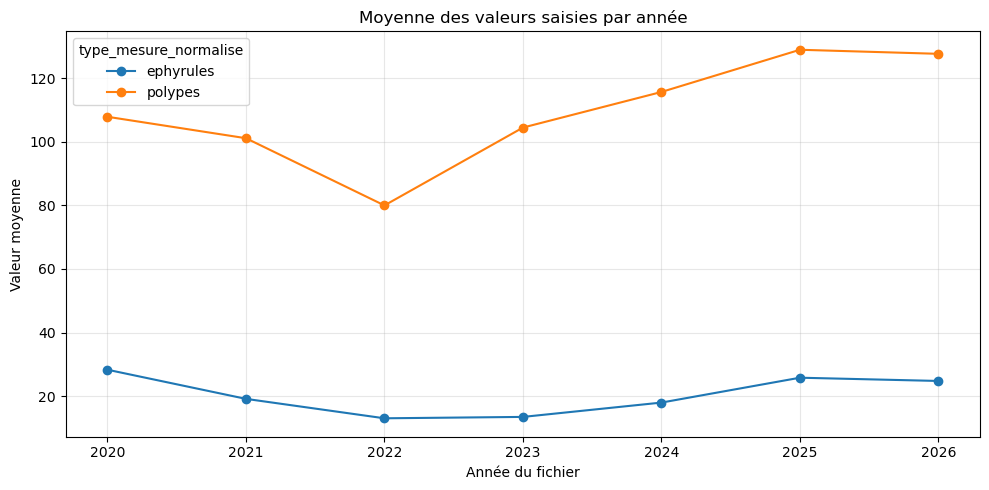

Commentaire :
Le total d'éphyrules saisi est le plus élevé en 2025, avec 210126 éphyrules cumulées.
Le total de polypes saisi est le plus élevé en 2025, avec 1049547 polypes cumulés.
Ces résultats décrivent les données saisies. Ils ne suffisent pas à conclure qu'une année est biologiquement meilleure, car le nombre de boîtes et de semaines suivies varie selon les années.


In [10]:
if not df_valeurs.empty:
    resume_annee = (
        df_valeurs
        .groupby(["annee_fichier", "type_mesure_normalise"])
        .agg(
            total=("valeur", "sum"),
            moyenne=("valeur", "mean"),
            mediane=("valeur", "median"),
            nb_valeurs=("valeur", "count"),
            nb_boites=("boite", "nunique"),
            nb_especes=("espece", "nunique")
        )
        .reset_index()
    )

    display(resume_annee)

    # Graphique simple des moyennes par année.
    plot_df = resume_annee.pivot(index="annee_fichier", columns="type_mesure_normalise", values="moyenne")
    ax = plot_df.plot(kind="line", marker="o", figsize=(10, 5))
    ax.set_title("Moyenne des valeurs saisies par année")
    ax.set_xlabel("Année du fichier")
    ax.set_ylabel("Valeur moyenne")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Commentaire :")
    annee_max_eph = resume_annee[resume_annee["type_mesure_normalise"] == "ephyrules"].sort_values("total", ascending=False).head(1)
    annee_max_pol = resume_annee[resume_annee["type_mesure_normalise"] == "polypes"].sort_values("total", ascending=False).head(1)
    if not annee_max_eph.empty:
        print(f"Le total d'éphyrules saisi est le plus élevé en {int(annee_max_eph.iloc[0]['annee_fichier'])}, avec {annee_max_eph.iloc[0]['total']:.0f} éphyrules cumulées.")
    if not annee_max_pol.empty:
        print(f"Le total de polypes saisi est le plus élevé en {int(annee_max_pol.iloc[0]['annee_fichier'])}, avec {annee_max_pol.iloc[0]['total']:.0f} polypes cumulés.")
    print("Ces résultats décrivent les données saisies. Ils ne suffisent pas à conclure qu'une année est biologiquement meilleure, car le nombre de boîtes et de semaines suivies varie selon les années.")
else:
    print("Pas de valeurs numériques pour produire le résumé annuel.")


## 9. Résumé par espèce

Ce bloc identifie les espèces qui ont les plus grands totaux d’éphyrules dans les données saisies.

Le tableau affiche aussi le nombre de valeurs, de boîtes et d’années, pour éviter d’interpréter trop vite un gros total.


,espece,type_mesure_normalise,total,moyenne,nb_valeurs,nb_boites,annees
70,Cephea cephea,ephyrules,45964.0,71.931142,639,7,7
254,Stomolophus sp.2,ephyrules,44467.0,121.494536,366,8,4
110,Clytia hemisphaerica,ephyrules,43152.0,118.224658,365,8,5
64,Catostylus mosaicus,ephyrules,39452.0,56.602582,697,9,7
152,Eirene lacteoides,ephyrules,38432.0,60.332810,637,9,7
178,Leuckartiara sp.,ephyrules,37509.0,59.069291,635,10,7
192,Lychnorhiza lucerna,ephyrules,34500.0,54.075235,638,5,7
120,Cotylorhiza tuberculata,ephyrules,24070.0,34.434907,699,15,7
250,Stomolophus meleagris,ephyrules,22267.0,59.378667,375,11,6
28,Aurelia limbata,ephyrules,21284.0,29.276479,727,10,7


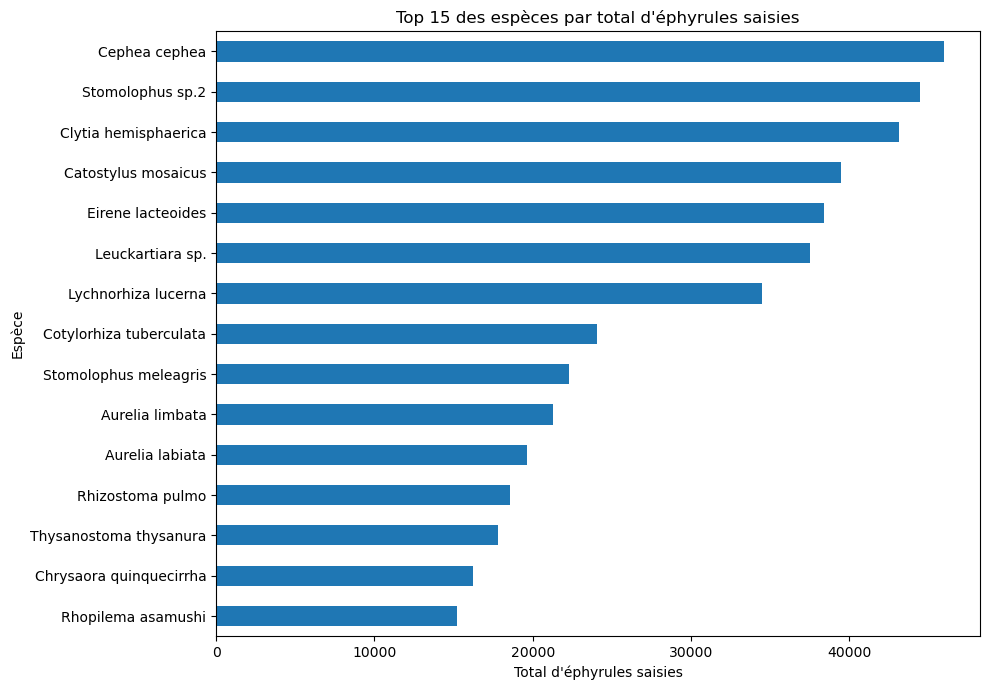

Commentaire :
Dans les données nettoyées, l'espèce avec le plus grand total d'éphyrules saisies est Cephea cephea, avec 45964 éphyrules cumulées.
Il faut comparer ce total avec le nombre de boîtes, d'années et de valeurs disponibles, car une espèce très suivie a plus de chances d'avoir un total élevé.
Ce classement sert donc surtout à repérer les espèces importantes à analyser plus finement.


In [11]:
if not df_valeurs.empty:
    resume_espece = (
        df_valeurs
        .groupby(["espece", "type_mesure_normalise"])
        .agg(
            total=("valeur", "sum"),
            moyenne=("valeur", "mean"),
            nb_valeurs=("valeur", "count"),
            nb_boites=("boite", "nunique"),
            annees=("annee_fichier", "nunique")
        )
        .reset_index()
    )

    top_ephyrules = (
        resume_espece[resume_espece["type_mesure_normalise"] == "ephyrules"]
        .sort_values("total", ascending=False)
        .head(15)
    )

    display(top_ephyrules)

    ax = top_ephyrules.sort_values("total").plot(
        kind="barh", x="espece", y="total", figsize=(10, 7), legend=False
    )
    ax.set_title("Top 15 des espèces par total d'éphyrules saisies")
    ax.set_xlabel("Total d'éphyrules saisies")
    ax.set_ylabel("Espèce")
    plt.tight_layout()
    plt.show()

    print("Commentaire :")
    if not top_ephyrules.empty:
        premiere = top_ephyrules.iloc[0]
        print(f"Dans les données nettoyées, l'espèce avec le plus grand total d'éphyrules saisies est {premiere['espece']}, avec {premiere['total']:.0f} éphyrules cumulées.")
        print("Il faut comparer ce total avec le nombre de boîtes, d'années et de valeurs disponibles, car une espèce très suivie a plus de chances d'avoir un total élevé.")
        print("Ce classement sert donc surtout à repérer les espèces importantes à analyser plus finement.")
else:
    print("Pas de valeurs numériques pour produire le résumé par espèce.")


## 10. Résumé par température

Ce bloc compare les valeurs selon les températures indiquées dans les fichiers.

C’est utile pour repérer des différences possibles entre températures, mais ce n’est pas une preuve de causalité. Les espèces, les années, les boîtes et les protocoles peuvent aussi expliquer les écarts.


,temperature,type_mesure_normalise,total,moyenne,mediane,nb_valeurs,nb_boites,nb_especes
0,5.0,ephyrules,51240.0,25.117647,0.0,2040,45,11
2,10.0,ephyrules,71471.0,13.699636,0.0,5217,120,41
4,15.0,ephyrules,185220.0,21.088466,0.0,8783,192,53
6,20.0,ephyrules,152876.0,15.874974,0.0,9630,220,53
8,25.0,ephyrules,218856.0,24.875654,0.0,8798,236,73
10,30.0,ephyrules,92612.0,26.235694,0.0,3530,87,30
1,5.0,polypes,298866.0,146.574792,150.0,2039,45,11
3,10.0,polypes,503903.0,97.016365,70.0,5194,120,41
5,15.0,polypes,729881.0,83.865449,50.0,8703,192,53
7,20.0,polypes,1014853.0,103.842525,80.0,9773,222,53


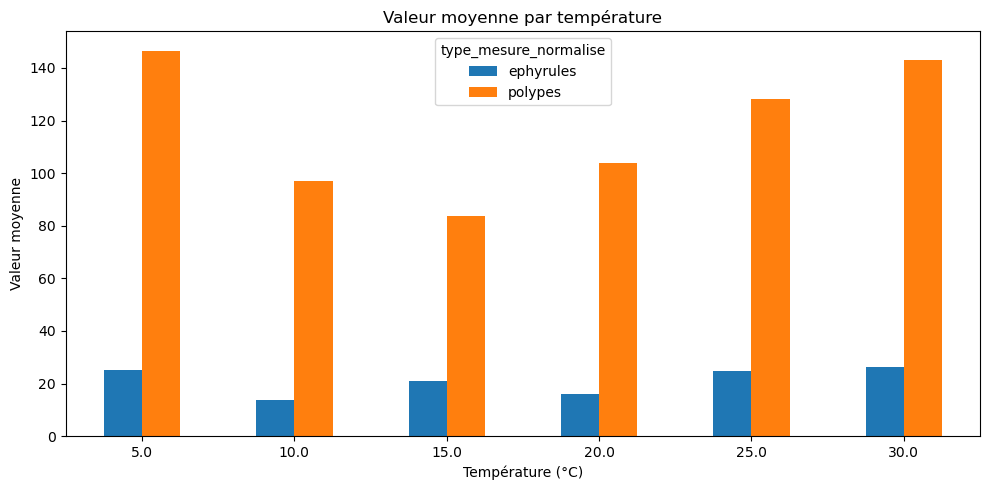

Commentaire :
La moyenne d'éphyrules la plus élevée apparaît à 30 °C dans les données disponibles.
Ce résultat doit être interprété prudemment : il peut dépendre des espèces présentes à chaque température, du nombre de boîtes suivies et des changements de conditions au cours de l'année.
Pour aller plus loin, il faudrait comparer les températures à espèce identique et tenir compte des repiquages ou changements de température.


In [12]:
if not df_valeurs.empty:
    resume_temperature = (
        df_valeurs
        .dropna(subset=["temperature"])
        .groupby(["temperature", "type_mesure_normalise"])
        .agg(
            total=("valeur", "sum"),
            moyenne=("valeur", "mean"),
            mediane=("valeur", "median"),
            nb_valeurs=("valeur", "count"),
            nb_boites=("boite", "nunique"),
            nb_especes=("espece", "nunique")
        )
        .reset_index()
        .sort_values(["type_mesure_normalise", "temperature"])
    )

    display(resume_temperature)

    plot_temp = resume_temperature.pivot(index="temperature", columns="type_mesure_normalise", values="moyenne")
    ax = plot_temp.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Valeur moyenne par température")
    ax.set_xlabel("Température (°C)")
    ax.set_ylabel("Valeur moyenne")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("Commentaire :")
    eph_temp = resume_temperature[resume_temperature["type_mesure_normalise"] == "ephyrules"]
    if not eph_temp.empty:
        meilleure = eph_temp.sort_values("moyenne", ascending=False).iloc[0]
        print(f"La moyenne d'éphyrules la plus élevée apparaît à {meilleure['temperature']:.0f} °C dans les données disponibles.")
    print("Ce résultat doit être interprété prudemment : il peut dépendre des espèces présentes à chaque température, du nombre de boîtes suivies et des changements de conditions au cours de l'année.")
    print("Pour aller plus loin, il faudrait comparer les températures à espèce identique et tenir compte des repiquages ou changements de température.")
else:
    print("Pas de valeurs numériques pour produire le résumé par température.")


## 11. Évolution d’une boîte précise

Ce bloc permet de suivre une boîte dans le temps. Il est utile pour passer d’une vision globale à un cas concret.

On peut changer `boite_choisie` pour analyser une autre boîte.


Boîte choisie : ALA-JKA-1.02


,annee_fichier,groupe,espece,temperature
21528,2020,Aurelia,Aurelia labiata,5.0
22610,2020,Aurelia,Aurelia labiata,15.0


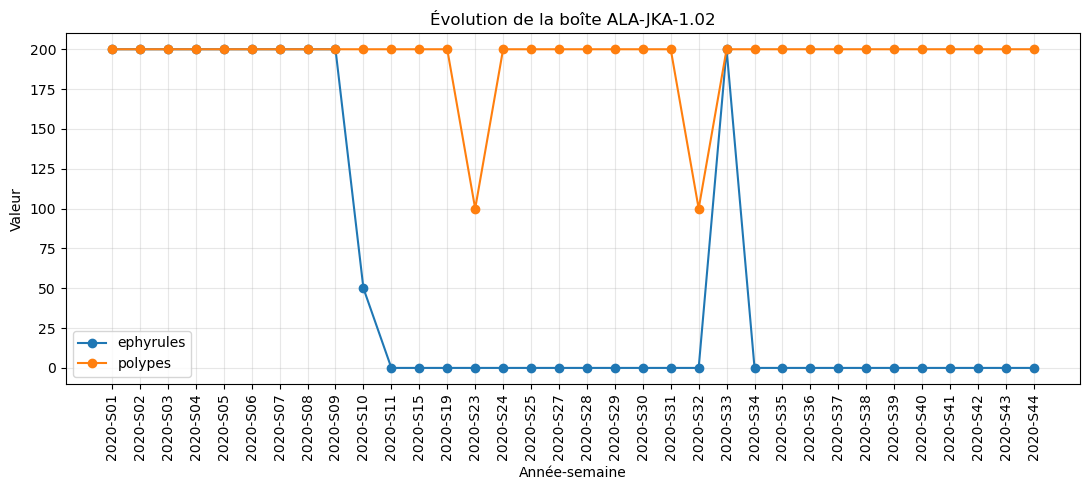

Commentaire :
Ce graphique permet de voir si la boîte reste stable, si elle produit des éphyrules, ou si une rupture apparaît dans le suivi.
Cette boîte apparaît avec plusieurs températures dans les données. Cela peut indiquer un changement de condition, mais il faut le vérifier dans le fichier d'origine et avec les tuteurs.
Les périodes vides ne sont pas dessinées comme des zéros, afin de ne pas créer de fausses chutes.


In [13]:
if not df_valeurs.empty:
    # Choix automatique d'une boîte, modifiable à la main.
    boite_choisie = df_valeurs["boite"].dropna().iloc[0]

    print("Boîte choisie :", boite_choisie)
    d = df_valeurs[df_valeurs["boite"] == boite_choisie].copy()

    display(d[["annee_fichier", "groupe", "espece", "temperature"]].drop_duplicates())

    fig, ax = plt.subplots(figsize=(11, 5))
    for mesure, sous_df in d.groupby("type_mesure_normalise"):
        sous_df = sous_df.sort_values(["annee_fichier", "semaine_index"])
        x = sous_df["annee_fichier"].astype(str) + "-S" + sous_df["semaine_index"].astype(str).str.zfill(2)
        ax.plot(x, sous_df["valeur"], marker="o", label=mesure)

    ax.set_title(f"Évolution de la boîte {boite_choisie}")
    ax.set_xlabel("Année-semaine")
    ax.set_ylabel("Valeur")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    print("Commentaire :")
    print("Ce graphique permet de voir si la boîte reste stable, si elle produit des éphyrules, ou si une rupture apparaît dans le suivi.")
    if d["temperature"].nunique() > 1:
        print("Cette boîte apparaît avec plusieurs températures dans les données. Cela peut indiquer un changement de condition, mais il faut le vérifier dans le fichier d'origine et avec les tuteurs.")
    print("Les périodes vides ne sont pas dessinées comme des zéros, afin de ne pas créer de fausses chutes.")
else:
    print("Pas de valeurs numériques pour afficher l'évolution d'une boîte.")


## 12. Détection simple des fortes variations

Ce bloc repère les grands changements d’une semaine à l’autre pour une même boîte.

Il peut signaler une chute de polypes, un pic d’éphyrules, une erreur de saisie ou un événement biologique intéressant. Les seuils utilisés sont simples et devront être ajustés avec les tuteurs.


In [14]:
if not df_valeurs.empty:
    df_variations = df_valeurs.sort_values(
        ["boite", "annee_fichier", "type_mesure_normalise", "semaine_index"]
    ).copy()

    df_variations["valeur_precedente"] = (
        df_variations
        .groupby(["boite", "annee_fichier", "type_mesure_normalise"])["valeur"]
        .shift(1)
    )

    df_variations["variation_absolue"] = df_variations["valeur"] - df_variations["valeur_precedente"]
    df_variations["variation_relative"] = df_variations["variation_absolue"] / df_variations["valeur_precedente"].replace(0, np.nan)

    SEUIL_VARIATION_ABSOLUE = 50
    SEUIL_VARIATION_RELATIVE = 0.5

    anomalies_simples = df_variations[
        (df_variations["variation_absolue"].abs() >= SEUIL_VARIATION_ABSOLUE) |
        (df_variations["variation_relative"].abs() >= SEUIL_VARIATION_RELATIVE)
    ].copy()

    display(anomalies_simples.sort_values("variation_absolue", key=lambda s: s.abs(), ascending=False).head(50))

    print("Commentaire :")
    print(f"Le tableau signale les variations d'au moins {SEUIL_VARIATION_ABSOLUE} unités ou {SEUIL_VARIATION_RELATIVE*100:.0f}% d'une valeur à la suivante.")
    print(f"Nombre de variations signalées : {len(anomalies_simples)}.")
    print("Ces lignes ne sont pas forcément des erreurs. Elles indiquent surtout des cas à vérifier : pic d'éphyrules, chute de polypes, changement de suivi ou saisie inhabituelle.")
else:
    print("Pas de valeurs numériques pour détecter les variations.")


,annee_fichier,groupe,espece,boite,temperature,type_mesure,type_mesure_normalise,semaine_index,colonne_excel,valeur,valeur_precedente,variation_absolue,variation_relative
121271,2023,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.04,15.0,Nb éphyrules,ephyrules,40,44,500.0,3000.0,-2500.0,-0.833333
121117,2023,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.04,15.0,Nb éphyrules,ephyrules,39,43,3000.0,1000.0,2000.0,2.000000
198227,2025,Hydrozoa,Ectopleura sp.,ECT-JKA-1.01,20.0,Nb éphyrules,ephyrules,45,49,1000.0,0.0,1000.0,NaN
155597,2024,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.07,15.0,Nb éphyrules,ephyrules,33,37,1000.0,0.0,1000.0,NaN
199651,2025,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.06,15.0,Nb éphyrules,ephyrules,51,55,1000.0,0.0,1000.0,NaN
198469,2025,Hydrozoa,Ectopleura sp.,ECT-JKA-1.01,20.0,Nb éphyrules,ephyrules,46,50,0.0,1000.0,-1000.0,-1.000000
155595,2024,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.06,15.0,Nb éphyrules,ephyrules,33,37,1000.0,0.0,1000.0,NaN
198977,2025,Hydrozoa,Eudendrium sp.,EUD-NBE-1.01,10.0,Nb éphyrules,ephyrules,48,52,1000.0,0.0,1000.0,NaN
155773,2024,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.06,15.0,Nb éphyrules,ephyrules,34,38,0.0,1000.0,-1000.0,-1.000000
118345,2023,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.04,15.0,Nb éphyrules,ephyrules,21,25,1000.0,0.0,1000.0,NaN


Commentaire :
Le tableau signale les variations d'au moins 50 unités ou 50% d'une valeur à la suivante.
Nombre de variations signalées : 13723.
Ces lignes ne sont pas forcément des erreurs. Elles indiquent surtout des cas à vérifier : pic d'éphyrules, chute de polypes, changement de suivi ou saisie inhabituelle.


## 13. Export de la table nettoyée

Ce bloc exporte la table au format CSV. Ce fichier peut servir pour d’autres analyses, pour tester un import SQL ou pour préparer la future structure de Polypbase.


In [15]:
if not df_suivi.empty:
    SORTIE_CSV = DATA_DIR / "suivi_polypes_format_long.csv"
    df_suivi.to_csv(SORTIE_CSV, index=False, encoding="utf-8-sig")

    print("CSV créé :", SORTIE_CSV)
    print("Commentaire :")
    print("Le fichier exporté contient les données en format long, plus facile à utiliser dans Python, Excel ou une base SQL.")
    print("L'encodage utf-8-sig est utilisé pour limiter les problèmes d'accents à l'ouverture dans Excel.")
else:
    print("Aucune donnée à exporter.")


CSV créé : suivi_polypes_format_long.csv
Commentaire :
Le fichier exporté contient les données en format long, plus facile à utiliser dans Python, Excel ou une base SQL.
L'encodage utf-8-sig est utilisé pour limiter les problèmes d'accents à l'ouverture dans Excel.


## 14. Premier regard sur les changements de température et repiquages

Ce fichier complémentaire semble plutôt décrire des événements ou un planning par mois. On l’affiche seulement pour comprendre sa structure.

Une analyse plus fiable demandera de savoir exactement ce que signifie chaque cellule remplie.


In [16]:
if FICHIER_CHANGEMENTS.exists():
    xls_chg = pd.ExcelFile(FICHIER_CHANGEMENTS)
    print("Feuilles trouvées :", xls_chg.sheet_names)

    for sheet in xls_chg.sheet_names:
        print("\nFeuille :", sheet)
        apercu = pd.read_excel(FICHIER_CHANGEMENTS, sheet_name=sheet, header=None).head(15)
        display(apercu)

    print("Commentaire :")
    print("Le fichier semble organisé par année, avec les espèces en lignes et les mois en colonnes.")
    print("Il faudra confirmer avec les tuteurs si les cellules remplies indiquent un repiquage, un changement de température, ou un autre événement.")
    print("Ce fichier pourra ensuite être croisé avec le suivi annuel pour mieux comprendre les périodes vides ou les changements de température.")
else:
    print("Fichier non trouvé :", FICHIER_CHANGEMENTS)


Feuilles trouvées : ['2022', '2023', '2024']

Feuille : 2022


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Planning repiquage de nouvelles boîtes et chan...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Année : 2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,J,F,M,A,M,J,J,A,S,O,N,D
5,Aequorea coerulescens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Aequorea victoria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Alatina morandini,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Aurelia labiata,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Aurelia limbata,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Feuille : 2023


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Planning repiquage de nouvelles boîtes et chan...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Année : 2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,J,F,M,A,M,J,J,A,S,O,N,D
5,Aequorea coerulescens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Aequorea macrodactyla,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Aequorea victoria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Alatina morandini,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Aurelia labiata,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Feuille : 2024


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Planning repiquage de nouvelles boîtes et chan...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Année 2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,J,F,M,A,M,J,J,A,S,O,N,D
5,Aequorea coerulescens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Aequorea macrodactyla,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Aequorea victoria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Alatina morandini,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Aurelia coerulea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Commentaire :
Le fichier semble organisé par année, avec les espèces en lignes et les mois en colonnes.
Il faudra confirmer avec les tuteurs si les cellules remplies indiquent un repiquage, un changement de température, ou un autre événement.
Ce fichier pourra ensuite être croisé avec le suivi annuel pour mieux comprendre les périodes vides ou les changements de température.


## 15. Premier regard sur le fichier de strobilation

Ce fichier semble contenir des informations sur le nombre de jours nécessaires à la strobilation selon certaines conditions.

Pour l’instant, on l’affiche seulement afin de comprendre sa forme. Les colonnes devront être validées avant une vraie analyse.


In [17]:
if FICHIER_STROBILATION.exists():
    xls_stro = pd.ExcelFile(FICHIER_STROBILATION)
    print("Feuilles trouvées :", xls_stro.sheet_names)

    strobilation = pd.read_excel(FICHIER_STROBILATION, sheet_name=xls_stro.sheet_names[0], header=None)
    display(strobilation.head(30))

    print("Commentaire :")
    print("Le fichier contient des espèces et plusieurs conditions possibles de strobilation, comme la température, la salinité, la lumière ou certaines substances.")
    print("Les données sont assez incomplètes dans l'aperçu. Il faudra vérifier le sens exact des colonnes avant de calculer des statistiques.")
else:
    print("Fichier non trouvé :", FICHIER_STROBILATION)


Feuilles trouvées : ['Feuil1', 'Feuil2', 'Feuil3']


,0,1,2,3,4,5,6
0,NaN,Nombre de jours pour la strobilation,NaN,NaN,NaN,NaN,NaN
1,Espèce,Température,Salinité,Lumière,Indométacine,2-méthyl-indole,Lugol
2,Aequorea coerulescens,NaN,NaN,NaN,NaN,NaN,NaN
3,Aequorea victoria,NaN,NaN,NaN,NaN,NaN,NaN
4,Aurelia aurita,NaN,NaN,NaN,NaN,NaN,NaN
5,Aurelia labiata,NaN,NaN,NaN,NaN,NaN,NaN
6,Aurelia limbata,NaN,NaN,NaN,NaN,NaN,NaN
7,Aurelia maldivensis,NaN,NaN,NaN,NaN,NaN,NaN
8,Carybdea marsupialis,NaN,NaN,NaN,NaN,NaN,NaN
9,Carybdea morandinii,NaN,NaN,NaN,NaN,NaN,NaN


Commentaire :
Le fichier contient des espèces et plusieurs conditions possibles de strobilation, comme la température, la salinité, la lumière ou certaines substances.
Les données sont assez incomplètes dans l'aperçu. Il faudra vérifier le sens exact des colonnes avant de calculer des statistiques.


## 16. Conclusion provisoire

Cette première analyse permet surtout de rendre les anciens fichiers Excel plus exploitables.

On observe que les données peuvent être regroupées dans une table commune, mais plusieurs points doivent être clarifiés avant d’aller plus loin : le sens des cellules vides, les changements de température, les repiquages, les noms de groupes à harmoniser et la différence entre température indiquée dans Excel et température réellement mesurée.
